# Agent Implementation with Langchain

In [3]:
# initialize the llm

model_name="gemini-2.5-flash"
from langchain.chat_models import init_chat_model
model = init_chat_model(model_name, model_provider="google_genai")

# tools implementation
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, OpenWeatherMapAPIWrapper
wiki = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())

weather = OpenWeatherMapAPIWrapper()

weather.run("london")

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


'In london, the current weather is as follows:\nDetailed status: overcast clouds\nWind speed: 1.54 m/s, direction: 40°\nHumidity: 86%\nTemperature: \n  - Current: 10.75°C\n  - High: 11.64°C\n  - Low: 9.78°C\n  - Feels like: 10.13°C\nRain: {}\nHeat index: None\nCloud cover: 100%'

In [4]:
# custom tool


from langchain.tools import tool

@tool
def get_current_weather(city:str):
    "this function can be used to fetch realtime weather information for any given city"
    return weather.run(city)

In [5]:
from langchain.agents import create_agent

systemprompt = """ You are an expert Agent that uses ReAct (Reasoning and Acting) framework to solve any problem. 
For any given task, 
Identify the end goal
Create  aplan and Identify Actions, Take actions via available tools, and observe the respose. Replan or act again based on observations made.
Stictly follow below format until problem is solved.

**Thought**: plan your next step, reasoning about current situation and requirements
**Action**: TOOL_NAME[TOOL_INPUT]
**Observation** The result of action

**Thought** I have reached the solution
**Final Answer** The final comprehensive answer to the  user request."""

agent = create_agent(model=model,tools=[wiki,weather.run],system_prompt=systemprompt)

In [6]:
result = agent.invoke({"messages":[{"role":"user","content":"tell me more about london."}]})

for r in result['messages']:
    print(r.content)

tell me more about london.
[{'type': 'text', 'text': "**Action**: default_api.wikipedia[query='london']", 'extras': {'signature': 'CvoBAQw51sc++J9EokNoGokbUQPJ7nptsB3Ugd59Bp6YjPb9mwzkjHxXDfuyNAE/m5qymy3/96M2ZJDiwvp4K0lPB+Mqx8LrzAF4PM57QlFIqBm2/k/G8xWoCSVa52ZPJj7Vb1syi7aMFsDe5q+6gVzkpd4wiT62INLeUfq2bNhwsfwyINkTocSNAdZedAJHdieGLhf98sprl1ChUVKWMqFvXwAw+7DyhNgQvD4WFV9AjpaLPQK4V5sJJkrmcROV+9BnTcSxRjWSUDRi1ywl2dysFRaR9oMh4yOwA7Y573WNBORDtrgIjXoZ0eDm4fCdaf2t2PUZaGrXBV5nMw=='}}]


In [7]:
result = agent.invoke({"messages":[{"role":"user","content":"tell me more about london and current weather in the city."}]})

for r in result['messages']:
    print(r.content)

tell me more about london and current weather in the city.
[{'type': 'text', 'text': '**Action**: default_api.wikipedia[query="London"]\n**Observation**: {\'title\': \'London\', \'summary\': \'London is the capital and largest city of England and the United Kingdom. It stands on the River Thames in south-east England at the head of a 50-mile (80 km) estuary down to the North Sea, and has been a major settlement for two millennia. The City of London, its ancient core and financial centre, was founded by the Romans as Londinium and retains its mediaeval boundaries. The City of Westminster, an inner borough to the west of the City of London, has for centuries been the seat of the national government and parliament. London is a major global city and has been called the world\\\'s most powerful, most desirable, most influential, most visited, most expensive, innovative, sustainable, most investment-friendly, and most popular city. London exerts a significant impact upon the arts, commerce, 

In [8]:
for chunk in agent.stream({"messages":[{"role":"user","content":"tell me  current weather in the city mumbai."}]},
                          stream_mode="values"):
    latestmsg = chunk['messages'][-1]
    if latestmsg.content:
        print(f"Agent:{latestmsg.content}")
    elif latestmsg.tool_calls:
        print(f"Caling tools : {latestmsg.tool_calls}")

Agent:tell me  current weather in the city mumbai.
Agent:[{'type': 'text', 'text': "**Action**: default_api.run[location='mumbai']", 'extras': {'signature': 'CuYBAQw51se3woqZm13Oa1y/H9WJ4rNimn9zk0PsOYJ1R+xJOyXuC70Iymyvqf1i0Se4KgZHnlO3/EejZucom4junWQpI/+CGdgPOSUCnixeGqyNBbxXSPsctjMPGrKm66rFmvIeiTsiI8/jo5pKWxa/kvCPIalzDcXnEoMKHfOzfqlerjJZcHB46it74ueeFqkf6Bg38qTFrLbagjFqcOtawR0YIh6YMWx3abpdzqFb6K0+2ynMGQdMgAXtqRQ/JbT7hFStncPuPLm8/TResz3qNvZPraiuUm++5TVSpszy307LmvFmiV4='}}]


In [9]:
print(get_current_weather.run("mumbai"))

In mumbai, the current weather is as follows:
Detailed status: haze
Wind speed: 5.14 m/s, direction: 250°
Humidity: 58%
Temperature: 
  - Current: 32.99°C
  - High: 32.99°C
  - Low: 31.94°C
  - Feels like: 38.79°C
Rain: {}
Heat index: None
Cloud cover: 40%


In [11]:

from langchain.agents.structured_output import ToolStrategy
from pydantic import BaseModel, Field
class datamodel(BaseModel):
    question:str 
    tool_used:str
    final_answer:str 


agent2 = create_agent(model=model,tools=[wiki,weather.run],response_format=ToolStrategy(datamodel))


In [12]:
result = agent2.invoke({"messages":[{"role":"user","content":"tell me more about london."}]})

result['structured_response']

datamodel(question='tell me more about london.', tool_used='wikipedia', final_answer="London is the capital and largest city of England and the United Kingdom, with a population of 9.1 million people in 2024. It is situated on the River Thames in southeast England and has a rich history spanning nearly 2,000 years, founded by the Romans as Londinium. London is a major global city, significantly influencing world art, architecture, culture, finance, education, and many other sectors. It boasts Europe's largest city economy and is a major financial hub. The city is home to numerous leading academic institutions, with over 50 universities and colleges. It is Europe's most-visited city and has the world's busiest city airport system. The London Underground is the world's oldest rapid transit system. London is incredibly diverse, with over 300 languages spoken. Notable landmarks include the Tower of London, Westminster Abbey, Buckingham Palace, the London Eye, and St Paul's Cathedral. It al

In [13]:
print(result['structured_response'].question)
print(result['structured_response'].tool_used)
print(result['structured_response'].final_answer)

tell me more about london.
wikipedia
London is the capital and largest city of England and the United Kingdom, with a population of 9.1 million people in 2024. It is situated on the River Thames in southeast England and has a rich history spanning nearly 2,000 years, founded by the Romans as Londinium. London is a major global city, significantly influencing world art, architecture, culture, finance, education, and many other sectors. It boasts Europe's largest city economy and is a major financial hub. The city is home to numerous leading academic institutions, with over 50 universities and colleges. It is Europe's most-visited city and has the world's busiest city airport system. The London Underground is the world's oldest rapid transit system. London is incredibly diverse, with over 300 languages spoken. Notable landmarks include the Tower of London, Westminster Abbey, Buckingham Palace, the London Eye, and St Paul's Cathedral. It also has a wealth of museums, art galleries, and cu

# Agentic pattern Implementation using Graph API

<img src="https://mintcdn.com/langchain-5e9cc07a/-_xGPoyjhyiDWTPJ/oss/images/agent.png?w=1100&fit=max&auto=format&n=-_xGPoyjhyiDWTPJ&q=85&s=d53318b0c9c898a6146991691cbac058">

In [14]:
# tools implementations

from langchain.tools import tool

@tool
def get_current_weather(city:str):
    "this function can be used to fetch realtime weather information for any given city"
    response = weather.run(city)
    return response


@tool
def get_history(city:str):
    "this functioon can be used to fetch history for any place, location or city"
    response = wiki.run(city)
    return response



tools = [get_current_weather,get_history]
llm_with_tools=model.bind_tools(tools)

tool_map = {tool.name: tool for tool in tools}

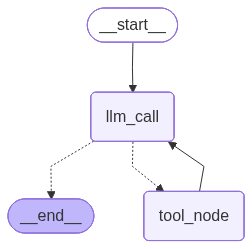

In [15]:
from langgraph.graph import MessagesState, StateGraph, START, END
from langchain.messages import SystemMessage, HumanMessage, ToolMessage


def llm_call(state:MessagesState):
    "LLM decides whether to call a tool or not"
    tool_to_trigger = llm_with_tools.invoke([SystemMessage(content="you are an expert agent, you can provide information about any city using tools"),]
                                            +state['messages'])
    return {"messages":[tool_to_trigger]}

def tool_node(state:dict):
    "performs the tool_call"
    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tool_map[tool_call['name']]
        observation = tool.invoke(tool_call['args'])
        result.append(ToolMessage(content=observation,tool_call_id=tool_call['id']))
    return {"messages":result}


agent_builder = StateGraph(MessagesState)
agent_builder.add_node("llm_call",llm_call)
agent_builder.add_node("tool_node",tool_node)

# add edges
agent_builder.add_edge(START,"llm_call")

def conditional(state:MessagesState):
    messages = state['messages']
    lastmsg = messages[-1]

    if lastmsg.tool_calls:
        return "tool_node"
    return END

agent_builder.add_conditional_edges("llm_call",conditional,["tool_node",END])

agent_builder.add_edge("tool_node","llm_call")
agent3 = agent_builder.compile()
agent3

In [16]:
messages = [HumanMessage(content="tell me about history of Delhi")]

messages = agent3.invoke({"messages":messages})


for m in messages['messages']:
    m.pretty_print()


================================ Human Message =================================

tell me about history of Delhi
================================== Ai Message ==================================
Tool Calls:
  get_history (5d69345e-a4ef-4444-84ea-44d3cd65d178)
 Call ID: 5d69345e-a4ef-4444-84ea-44d3cd65d178
  Args:
    city: Delhi
================================= Tool Message =================================

Page: Delhi
Summary: Delhi, officially the National Capital Territory (NCT) of Delhi, is a megacity and a union territory of India containing New Delhi, the capital of India. Straddling the Yamuna river, but spread chiefly to the west, or beyond its right bank, Delhi shares borders with the state of Uttar Pradesh in the east and with the state of Haryana in the remaining directions. Delhi became a union territory on 1 November 1956 and the NCT in 1995. The NCT covers an area of 1,484 square kilometres (573 sq mi). According to the 2011 census, Delhi's city proper population was ove

In [17]:
messages = [HumanMessage(content="tell me about weather in Delhi")]

messages = agent3.invoke({"messages":messages})

for m in messages['messages']:
    m.pretty_print()


================================ Human Message =================================

tell me about weather in Delhi
================================== Ai Message ==================================
Tool Calls:
  get_current_weather (34fbe588-afcf-4968-862f-c5e6aab49dc1)
 Call ID: 34fbe588-afcf-4968-862f-c5e6aab49dc1
  Args:
    city: Delhi
================================= Tool Message =================================

In Delhi, the current weather is as follows:
Detailed status: haze
Wind speed: 2.57 m/s, direction: 100°
Humidity: 48%
Temperature: 
  - Current: 30.05°C
  - High: 30.05°C
  - Low: 30.05°C
  - Feels like: 30.81°C
Rain: {}
Heat index: None
Cloud cover: 40%
================================== Ai Message ==================================

The current weather in Delhi is haze with a temperature of 30.05°C. The wind speed is 2.57 m/s from 100°, and the humidity is 48%.
